# Lab 04: Ames Iowa Home Prices

---
author: Isabella Iniguez
date: October 7, 2024
embed-resources: true
---

## Introduction

## Methods

In [24]:
# imports
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor


### Data

In [25]:
# load data
ames_train = pd.read_csv(
    "https://cs307.org/lab-04/data/ames-train.csv",
)
ames_test = pd.read_csv(
    "https://cs307.org/lab-04/data/ames-test.csv",
)
ames_train

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,2832,908188140,160,RM,24.0,2522,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,137500
1,2736,905426150,80,RL,NaN,19690,Pave,NaN,IR1,Lvl,...,738,Gd,GdPrv,NaN,0,8,2006,WD,Alloca,274970
2,2135,907200130,20,RL,97.0,11800,Pave,NaN,IR1,Bnk,...,0,NaN,NaN,NaN,0,8,2007,WD,Family,131000
3,2424,528228415,120,RM,NaN,3072,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,178740
4,1967,535457020,20,RL,80.0,8000,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,11,2007,WD,Normal,156500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1870,1020,527302070,20,RL,NaN,10825,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,181900
1871,237,905426200,20,RL,65.0,11479,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,144500
1872,1547,910202050,30,RM,40.0,3636,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,1,2008,WD,Normal,55000
1873,1855,533251110,20,RL,80.0,12000,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,255000


In [26]:
# summary statistics
print("Number of Samples: ", len(ames_train))
print("Number of Features: ", len(ames_train.columns)-1)

Number of Samples:  1875
Number of Features:  81


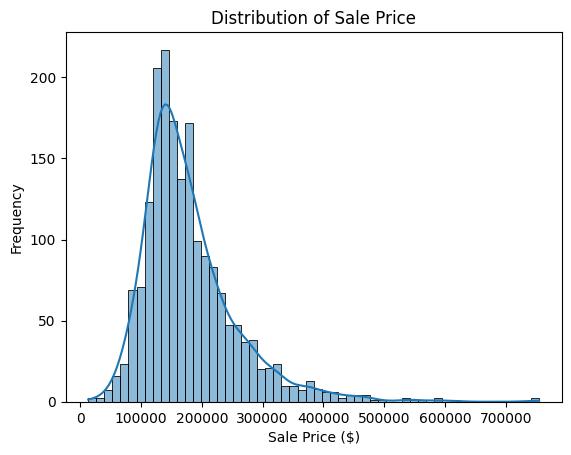

In [27]:
# visualizations
sns.histplot(ames_train["SalePrice"], kde=True)
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price ($)")
plt.ylabel("Frequency")
plt.show()

### Models

In [28]:
# process data for ML
# create X and y for train dataset
X_train = ames_train.drop("SalePrice", axis=1)
y_train = ames_train["SalePrice"]

# create X and y for test dataset
X_test = ames_test.drop("SalePrice", axis=1)
y_test = ames_test["SalePrice"]

In [29]:
# helper function to find columns that are mostly missing
def columns_missing_above_threshold(df, threshold):
    missing_proportion = df.isnull().sum() / len(df)
    columns_above_threshold = missing_proportion[missing_proportion > threshold].index.tolist()
    return columns_above_threshold

In [30]:
# define columns to be excluded
many_missing_columns = columns_missing_above_threshold(X_train, 0.6)
exclude_columns = ["Order", "PID"] + many_missing_columns

# find columns with string data type (will be considered categorical)
string_columns = X_train.select_dtypes(include=["object"]).columns.tolist()
string_columns = [col for col in string_columns if col not in exclude_columns]

# find columns with numeric data type
numeric_columns = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_columns = [col for col in numeric_columns if col not in exclude_columns]

In [31]:
# pipeline for numeric
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# pipeline for categorical
categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown='infrequent_if_exist', max_categories=5)),
    ]
)

# column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("ExcludeColumns", "drop", exclude_columns),
        ("CategoricalPreprocessing", categorical_preprocessor, string_columns),
        ("NumericProcessing", numeric_preprocessor, numeric_columns),
    ]
)

# full pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("Regressor", DummyRegressor()),
    ]
)

In [32]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ExcludeColumns', 'drop',
                                                  ['Order', 'PID', 'Alley',
                                                   'Pool QC', 'Fence',
                                                   'Misc Feature']),
                                                 ('CategoricalPreprocessing',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                 max_categories=5))]),
                                                  ['MS Zoning', 'Street',
                                                   'Lot Sh...
                                                   'Year Remod/Add',
                                                   'Mas Vnr Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   '1st Flr SF', '2nd Flr SF',
                                                   'Low Qual Fin SF',
                                                   'Gr Liv Area',
                                                   'Bsmt Full Bath',
                                                   'Bsmt Half Bath',
                                                   'Full Bath', 'Half Bath',
                                                   'Bedroom AbvGr',
                                                   'Kitchen AbvGr',
                                                   'TotRms AbvGrd',
                                                   'Fireplaces',
                                                   'Garage Yr Blt',
                                                   'Garage Cars', 'Garage Area',
                                                   'Wood Deck SF',
                                                   'Open Porch SF',
                                                   'Enclosed Porch', ...])])),
                ('Regressor', DummyRegressor())])

In [33]:
param_grid = [
    {
        "Regressor": [DummyRegressor()],
    },
    {
        "Regressor": [LinearRegression()],
    },
    {
        "Regressor": [KNeighborsRegressor()],
        "Regressor__n_neighbors": [1, 3, 5, 7, 9, 11, 15],
    },
    {
        "Regressor": [DecisionTreeRegressor()],
        "Regressor__max_depth": [1, 3, 5, 7, 9, 11, 15, None],
    },
    {
        "Regressor": [HistGradientBoostingRegressor()],
        "Regressor__learning_rate": [0.1, 0.01, 0.001],
        "Regressor__max_iter": [1000],
        "Regressor__max_depth": [None, 3],
        "Regressor__l2_regularization": [0.1, 1.0],
    },
]

In [34]:
mod = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    n_jobs=-1,
    cv=5,
    verbose=2,
    scoring="neg_mean_absolute_percentage_error",
)

In [35]:
mod.fit(X_train,y_train)

Fitting 5 folds for each of 29 candidates, totalling 145 fits
[CV] END .........................Regressor=DummyRegressor(); total time=   0.1s
[CV] END .........................Regressor=DummyRegressor(); total time=   0.1s
[CV] END .........................Regressor=DummyRegressor(); total time=   0.1s
[CV] END .........................Regressor=DummyRegressor(); total time=   0.1s
[CV] END .........................Regressor=DummyRegressor(); total time=   0.1s
[CV] END .......................Regressor=LinearRegression(); total time=   0.1s
[CV] END .......................Regressor=LinearRegression(); total time=   0.1s
[CV] END .......................Regressor=LinearRegression(); total time=   0.1s
[CV] END .......................Regressor=LinearRegression(); total time=   0.2s
[CV] END Regressor=KNeighborsRegressor(), Regressor__n_neighbors=1; total time=   0.1s
[CV] END Regressor=KNeighborsRegressor(), Regressor__n_neighbors=1; total time=   0.1s
[CV] END Regressor=KNeighborsRegres

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('ExcludeColumns',
                                                                         'drop',
                                                                         ['Order',
                                                                          'PID',
                                                                          'Alley',
                                                                          'Pool '
                                                                          'QC',
                                                                          'Fence',
                                                                          'Misc '
                                                                          'Feature']),
                                                                        ('CategoricalPreprocessing',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                                        max_categories=5...
                          'Regressor__n_neighbors': [1, 3, 5, 7, 9, 11, 15]},
                         {'Regressor': [DecisionTreeRegressor()],
                          'Regressor__max_depth': [1, 3, 5, 7, 9, 11, 15,
                                                   None]},
                         {'Regressor': [HistGradientBoostingRegressor()],
                          'Regressor__l2_regularization': [0.1, 1.0],
                          'Regressor__learning_rate': [0.1, 0.01, 0.001],
                          'Regressor__max_depth': [None, 3],
                          'Regressor__max_iter': [1000]}],
             scoring='neg_mean_absolute_percentage_error', verbose=2)

In [36]:
# print best parameters found and best (cross-validated) score
print(f"Best parameters: {mod.best_params_}")
print(f"Best cross-validation MAPE: {-mod.best_score_}")

Best parameters: {'Regressor': HistGradientBoostingRegressor(), 'Regressor__l2_regularization': 1.0, 'Regressor__learning_rate': 0.01, 'Regressor__max_depth': None, 'Regressor__max_iter': 1000}
Best cross-validation MAPE: 0.09323748138117231


## Results

In [37]:
# final evaluation on test set
y_pred = mod.predict(X_test)
print(f"Test set MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")

Test set MAPE: 0.08164649164771304


## Discussion

### Conclusion

In [38]:
from joblib import dump
dump(mod, "ames-housing.joblib")

['ames-housing.joblib']